In [1]:
# ライブラリのインポート
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# タイタニックデータの読み込み
titanic = sns.load_dataset('titanic')

print("🚢 タイタニックデータを読み込みました")
print(f"データの形状: {titanic.shape}")
print(f"\n各列のデータ型:")
print(titanic.dtypes)

🚢 タイタニックデータを読み込みました
データの形状: (891, 15)

各列のデータ型:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


In [2]:
# 欠損値の確認（前処理の前に現状を把握する）
print("❓ 欠損値の現状:")
print("=" * 50)

missing = titanic.isnull().sum()
missing_percent = (titanic.isnull().sum() / len(titanic) * 100).round(1)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_percent(%)': missing_percent
})

print(missing_df[missing_df['missing_count'] > 0])
print(f"\n全体の行数: {len(titanic)} 件")

❓ 欠損値の現状:
             missing_count  missing_percent(%)
age                    177                19.9
embarked                 2                 0.2
deck                   688                77.2
embark_town              2                 0.2

全体の行数: 891 件


In [3]:
# 機械学習に使用する列を選択
# 不要な列・重複する列・欠損が多すぎる列を除外する

# 除外する列とその理由
drop_columns = {
    'deck':        '欠損率77.2%で使用不可',
    'embark_town': 'embarkedと同じ情報（重複）',
    'alive':       'survivedと同じ情報（重複）',
    'class':       'pclassと同じ情報（重複）',
    'who':         'sex・ageから判断できる（重複）',
    'adult_male':  'sex・ageから判断できる（重複）'
}

print("🗑️ 削除する列と理由:")
print("=" * 50)
for col, reason in drop_columns.items():
    print(f"  {col:15s}: {reason}")

# 列を削除
df = titanic.drop(columns=drop_columns.keys())

print(f"\n削除前: {titanic.shape[1]} 列")
print(f"削除後: {df.shape[1]} 列")
print(f"\n残った列: {list(df.columns)}")

🗑️ 削除する列と理由:
  deck           : 欠損率77.2%で使用不可
  embark_town    : embarkedと同じ情報（重複）
  alive          : survivedと同じ情報（重複）
  class          : pclassと同じ情報（重複）
  who            : sex・ageから判断できる（重複）
  adult_male     : sex・ageから判断できる（重複）

削除前: 15 列
削除後: 9 列

残った列: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']


In [4]:
# 欠損値を補完する
print("🔧 欠損値の補完:")
print("=" * 50)

# age（年齢）→ 中央値で補完
# なぜ中央値？ → 平均値は外れ値（極端に高い/低い年齢）に影響されるが、
#                中央値は影響を受けにくいため
age_median = df['age'].median()
df['age'] = df['age'].fillna(age_median)
print(f"✅ age: 中央値 {age_median} で補完")

# embarked（乗船港）→ 最頻値で補完
# なぜ最頻値？ → カテゴリデータ（文字列）なので平均・中央値が使えない
#                最も多い値で埋めるのが一般的
embarked_mode = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(embarked_mode)
print(f"✅ embarked: 最頻値 '{embarked_mode}' で補完")

# 補完後の欠損値確認
print(f"\n補完後の欠損値:")
print(df.isnull().sum())
print(f"\n✅ 欠損値がすべて 0 になればOK！")

🔧 欠損値の補完:
✅ age: 中央値 28.0 で補完
✅ embarked: 最頻値 'S' で補完

補完後の欠損値:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64

✅ 欠損値がすべて 0 になればOK！


In [5]:
# 現在のデータ型を確認
# object型 = 文字列 → 数値に変換が必要
print("📋 各列のデータ型:")
print("=" * 50)

for col in df.columns:
    dtype = df[col].dtype
    unique = df[col].nunique()
    sample = df[col].unique()[:5]
    marker = "⚠️ 変換が必要" if dtype == 'object' or dtype == 'bool' else "✅ そのまま使える"
    print(f"  {col:12s} | {str(dtype):10s} | {marker} | 例: {sample}")

📋 各列のデータ型:
  survived     | int64      | ✅ そのまま使える | 例: [0 1]
  pclass       | int64      | ✅ そのまま使える | 例: [3 1 2]
  sex          | object     | ⚠️ 変換が必要 | 例: ['male' 'female']
  age          | float64    | ✅ そのまま使える | 例: [22. 38. 26. 35. 28.]
  sibsp        | int64      | ✅ そのまま使える | 例: [1 0 3 4 2]
  parch        | int64      | ✅ そのまま使える | 例: [0 1 2 5 3]
  fare         | float64    | ✅ そのまま使える | 例: [ 7.25   71.2833  7.925  53.1     8.05  ]
  embarked     | object     | ⚠️ 変換が必要 | 例: ['S' 'C' 'Q']
  alone        | bool       | ⚠️ 変換が必要 | 例: [False  True]


In [6]:
# カテゴリ変数を数値に変換する
print("🔄 カテゴリ変数のエンコーディング:")
print("=" * 50)

# sex（性別）→ 0/1に変換（Label Encoding）
# male=0, female=1
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
print("✅ sex: male=0, female=1 に変換")

# embarked（乗船港）→ ダミー変数に変換（One-Hot Encoding）
# なぜダミー変数？ → S=0, C=1, Q=2 とすると「QはSの2倍」
# という意味のない大小関係ができてしまうため
# S/C/Q をそれぞれ独立した列にする
df = pd.get_dummies(df, columns=['embarked'], prefix='embarked', dtype=int)
print("✅ embarked: ダミー変数（embarked_C, embarked_Q, embarked_S）に変換")

# alone（一人で乗船）→ True/Falseを0/1に変換
df['alone'] = df['alone'].astype(int)
print("✅ alone: True=1, False=0 に変換")

print(f"\n変換後のデータ型:")
print(df.dtypes)
print(f"\n変換後の列: {list(df.columns)}")

🔄 カテゴリ変数のエンコーディング:
✅ sex: male=0, female=1 に変換
✅ embarked: ダミー変数（embarked_C, embarked_Q, embarked_S）に変換
✅ alone: True=1, False=0 に変換

変換後のデータ型:
survived        int64
pclass          int64
sex             int64
age           float64
sibsp           int64
parch           int64
fare          float64
alone           int32
embarked_C      int32
embarked_Q      int32
embarked_S      int32
dtype: object

変換後の列: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'alone', 'embarked_C', 'embarked_Q', 'embarked_S']


In [7]:
# 前処理完了後のデータを確認
print("📊 前処理完了後のデータ:")
print("=" * 50)
print(f"形状: {df.shape}")
print(f"\n最初の5行:")
df.head()

📊 前処理完了後のデータ:
形状: (891, 11)

最初の5行:


,survived,pclass,sex,age,sibsp,parch,fare,alone,embarked_C,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,0,0,0,1
1,1,1,1,38.0,1,0,71.2833,0,1,0,0
2,1,3,1,26.0,0,0,7.9250,1,0,0,1
3,1,1,1,35.0,1,0,53.1000,0,0,0,1
4,0,3,0,35.0,0,0,8.0500,1,0,0,1


In [8]:
# 特徴量（X）とターゲット（y）を分離する
# X = モデルに与える入力データ（生存以外の列）
# y = モデルが予測する正解データ（生存したかどうか）

X = df.drop('survived', axis=1)  # survived以外の全列
y = df['survived']                # survivedだけ

print("🎯 特徴量（X）とターゲット（y）の分離:")
print("=" * 50)
print(f"X（特徴量）の形状: {X.shape} → {X.shape[0]}人分 × {X.shape[1]}個の特徴")
print(f"y（ターゲット）の形状: {y.shape} → {y.shape[0]}人分の生存データ")
print(f"\n特徴量の列: {list(X.columns)}")
print(f"\nターゲットの内訳:")
print(f"  死亡(0): {(y==0).sum()} 人")
print(f"  生存(1): {(y==1).sum()} 人")

🎯 特徴量（X）とターゲット（y）の分離:
X（特徴量）の形状: (891, 10) → 891人分 × 10個の特徴
y（ターゲット）の形状: (891,) → 891人分の生存データ

特徴量の列: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'alone', 'embarked_C', 'embarked_Q', 'embarked_S']

ターゲットの内訳:
  死亡(0): 549 人
  生存(1): 342 人


In [9]:
# 訓練データとテストデータに分割する
from sklearn.model_selection import train_test_split

# test_size=0.2 → 全体の20%をテスト用、80%を訓練用に使う
# random_state=42 → 毎回同じ分割結果にする（再現性のため）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✂️ データの分割:")
print("=" * 50)
print(f"訓練データ: {X_train.shape[0]} 人（全体の80%）")
print(f"テストデータ: {X_test.shape[0]} 人（全体の20%）")

✂️ データの分割:
訓練データ: 712 人（全体の80%）
テストデータ: 179 人（全体の20%）


In [10]:
# モデル1：ロジスティック回帰（Logistic Regression）
from sklearn.linear_model import LogisticRegression

# モデルを作成
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# 訓練データで学習（fit）
lr_model.fit(X_train, y_train)

# テストデータで予測（predict）
lr_pred = lr_model.predict(X_test)

# 正解率を確認
lr_accuracy = (lr_pred == y_test).mean()

print("📈 モデル1：ロジスティック回帰")
print("=" * 50)
print(f"正解率（Accuracy）: {lr_accuracy:.4f}（{lr_accuracy*100:.1f}%）")
print(f"\n予測結果の最初の10件:")
print(f"  予測: {list(lr_pred[:10])}")
print(f"  正解: {list(y_test[:10].values)}")

📈 モデル1：ロジスティック回帰
正解率（Accuracy）: 0.7989（79.9%）

予測結果の最初の10件:
  予測: [0, 0, 0, 1, 1, 1, 1, 0, 1, 1]
  正解: [1, 0, 0, 1, 1, 1, 1, 0, 1, 1]


In [11]:
# モデル2：ランダムフォレスト（Random Forest）
from sklearn.ensemble import RandomForestClassifier

# モデルを作成
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 訓練データで学習（fit）
rf_model.fit(X_train, y_train)

# テストデータで予測（predict）
rf_pred = rf_model.predict(X_test)

# 正解率を確認
rf_accuracy = (rf_pred == y_test).mean()

print("🌳 モデル2：ランダムフォレスト")
print("=" * 50)
print(f"正解率（Accuracy）: {rf_accuracy:.4f}（{rf_accuracy*100:.1f}%）")
print(f"\n予測結果の最初の10件:")
print(f"  予測: {list(rf_pred[:10])}")
print(f"  正解: {list(y_test[:10].values)}")

# 2つのモデルを比較
print(f"\n📊 モデル比較:")
print("=" * 50)
print(f"  ロジスティック回帰:  {lr_accuracy*100:.1f}%")
print(f"  ランダムフォレスト:  {rf_accuracy*100:.1f}%")

if rf_accuracy > lr_accuracy:
    print(f"\n🏆 ランダムフォレストが {(rf_accuracy-lr_accuracy)*100:.1f}% 上回りました！")
elif lr_accuracy > rf_accuracy:
    print(f"\n🏆 ロジスティック回帰が {(lr_accuracy-rf_accuracy)*100:.1f}% 上回りました！")
else:
    print(f"\n🤝 両モデルが同じ正解率です！")

🌳 モデル2：ランダムフォレスト
正解率（Accuracy）: 0.8212（82.1%）

予測結果の最初の10件:
  予測: [0, 0, 0, 1, 0, 1, 1, 0, 1, 1]
  正解: [1, 0, 0, 1, 1, 1, 1, 0, 1, 1]

📊 モデル比較:
  ロジスティック回帰:  79.9%
  ランダムフォレスト:  82.1%

🏆 ランダムフォレストが 2.2% 上回りました！


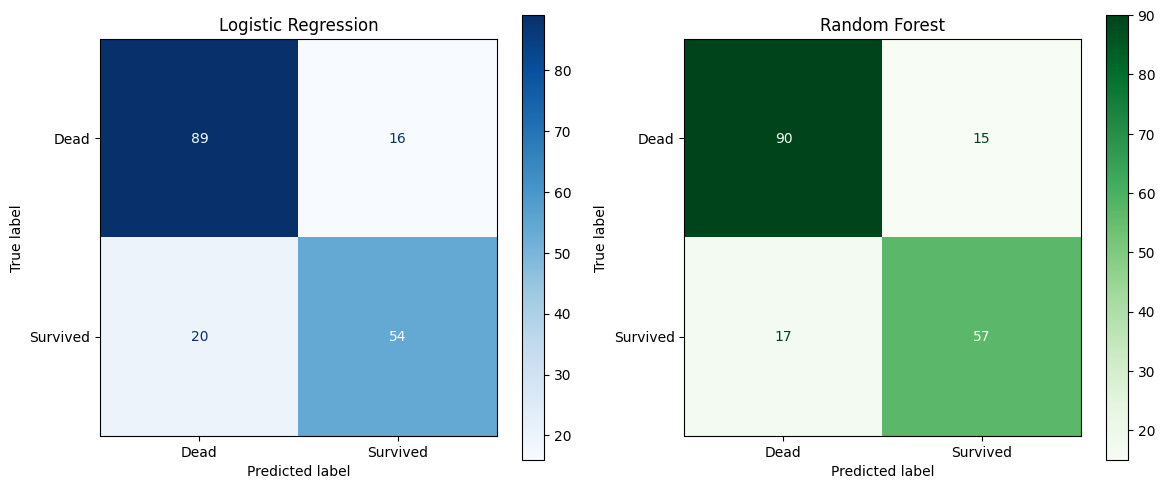

✅ 混同行列を outputs/ フォルダに保存しました


In [12]:
# 混同行列で詳しく評価する
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ロジスティック回帰の混同行列
cm_lr = confusion_matrix(y_test, lr_pred)
disp_lr = ConfusionMatrixDisplay(cm_lr, display_labels=['Dead', 'Survived'])
disp_lr.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression')

# ランダムフォレストの混同行列
cm_rf = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=['Dead', 'Survived'])
disp_rf.plot(ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png')
plt.show()

print("✅ 混同行列を outputs/ フォルダに保存しました")

In [13]:
# 各種評価スコアを確認
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

print("📊 詳細な評価スコア:")
print("=" * 60)

# ロジスティック回帰
print("\n【ロジスティック回帰】")
print(classification_report(y_test, lr_pred, target_names=['Dead', 'Survived']))

# ランダムフォレスト
print("【ランダムフォレスト】")
print(classification_report(y_test, rf_pred, target_names=['Dead', 'Survived']))

# わかりやすい比較表
print("📋 モデル比較まとめ:")
print("=" * 60)
print(f"{'指標':<15} {'ロジスティック回帰':>15} {'ランダムフォレスト':>15}")
print("-" * 60)

for name, y_pred in [('ロジスティック回帰', lr_pred), ('ランダムフォレスト', rf_pred)]:
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

metrics = {
    'Accuracy（正解率）': [accuracy_score(y_test, lr_pred), accuracy_score(y_test, rf_pred)],
    'Precision（適合率）': [precision_score(y_test, lr_pred), precision_score(y_test, rf_pred)],
    'Recall（再現率）': [recall_score(y_test, lr_pred), recall_score(y_test, rf_pred)],
    'F1 Score': [f1_score(y_test, lr_pred), f1_score(y_test, rf_pred)]
}

for metric, values in metrics.items():
    print(f"  {metric:<20} | {values[0]:.4f} | {values[1]:.4f}")

📊 詳細な評価スコア:

【ロジスティック回帰】
              precision    recall  f1-score   support

        Dead       0.82      0.85      0.83       105
    Survived       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

【ランダムフォレスト】
              precision    recall  f1-score   support

        Dead       0.84      0.86      0.85       105
    Survived       0.79      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

📋 モデル比較まとめ:
指標                    ロジスティック回帰       ランダムフォレスト
------------------------------------------------------------
  Accuracy（正解率）        | 0.7989 | 0.8212
  Precision（適合率）       | 0.7714 | 0.7917
  Recall（再現率）          | 0.7297 | 0.7703
  F1 Score             | 0.7500 | 0.7808
